In [38]:
# ЧАСТЬ 1: EDA и Preprocessing
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('german_credit_data.csv', index_col=0)

print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
display(df.head())


Размер датасета: (1000, 9)

Первые 5 строк:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [39]:
# 1.1 Первичный осмотр данных
print("ИНФОРМАЦИЯ О ДАННЫХ")
print(df.info())

print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
display(df.describe(include='all'))

# Проверка пропущенных значений
print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

ИНФОРМАЦИЯ О ДАННЫХ
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 78.1+ KB
None
ОПИСАТЕЛЬНАЯ СТАТИСТИКА


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8
top,NaN,male,NaN,own,little,little,NaN,NaN,car
freq,NaN,690,NaN,713,603,274,NaN,NaN,337
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN


ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ
                  Missing  Percent
Saving accounts       183     18.3
Checking account      394     39.4



Числовые признаки: ['Age', 'Job', 'Credit amount', 'Duration']
Категориальные признаки: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


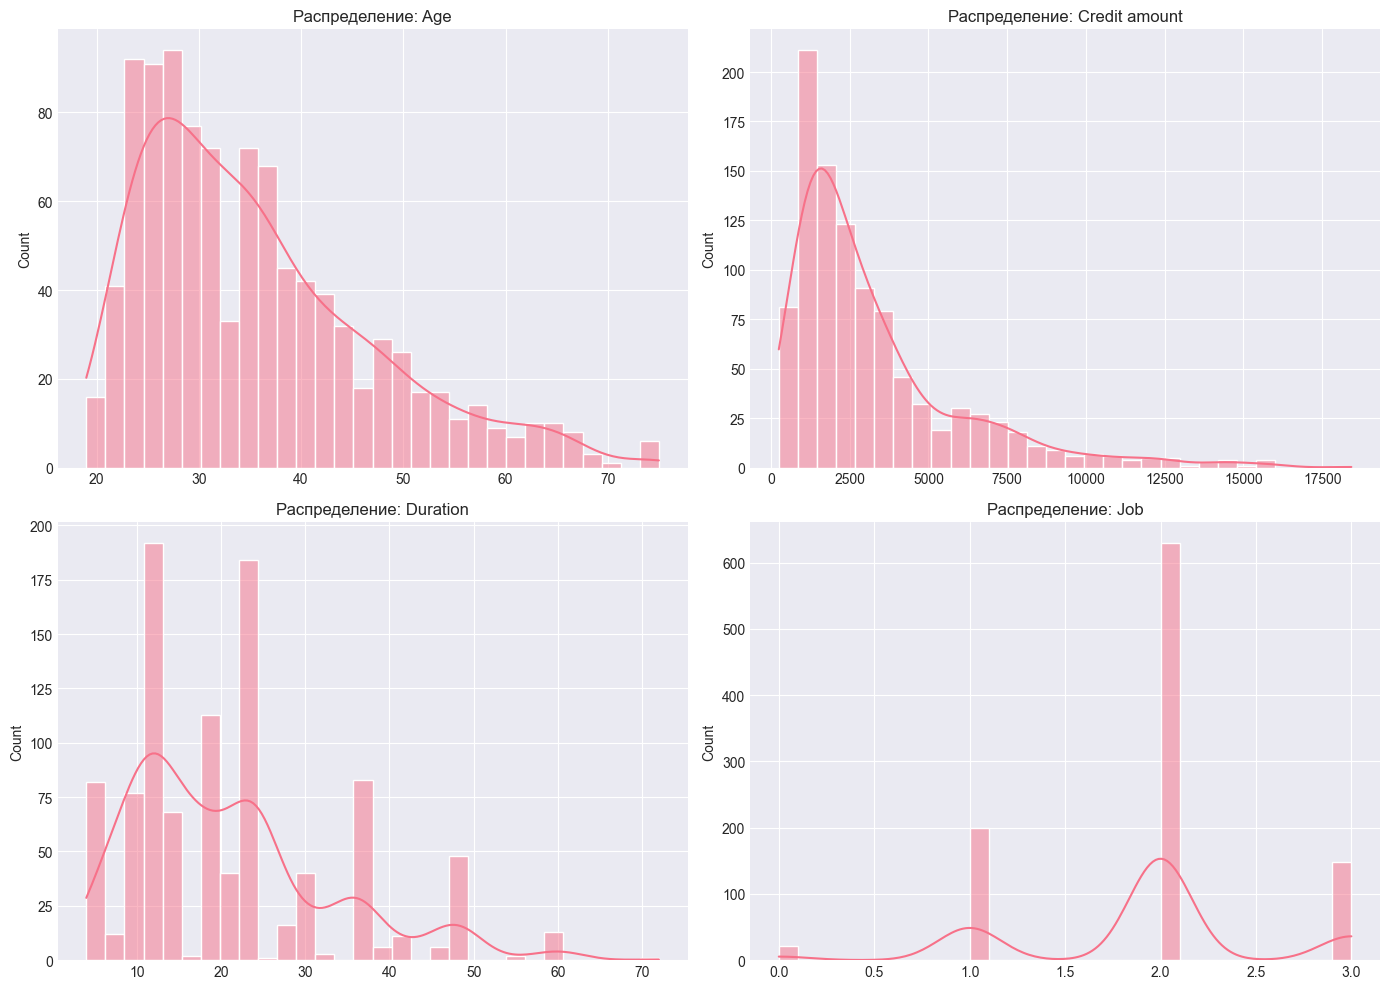

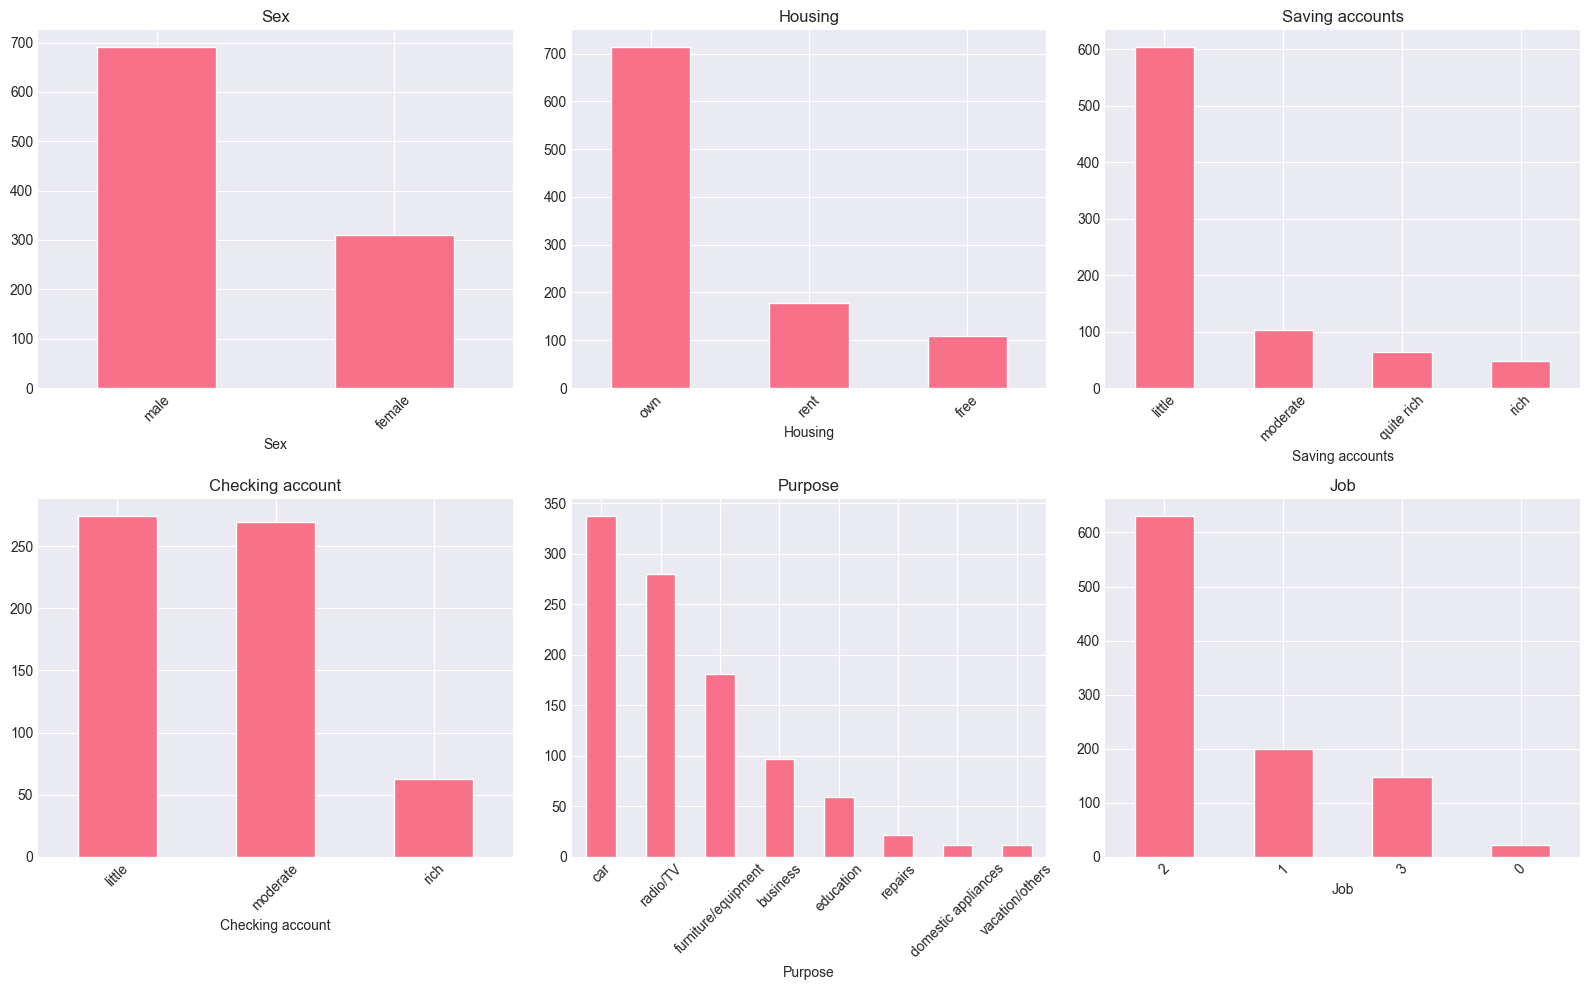

In [40]:
# 1.2 EDA: Визуализация распределений признаков

# Разделение на числовые и категориальные признаки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nЧисловые признаки: {numeric_cols}")
print(f"Категориальные признаки: {categorical_cols}")

# Гистограммы для числовых признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(['Age', 'Credit amount', 'Duration', 'Job']):
    ax = axes[idx//2, idx%2]
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Барплоты для категориальных признаков
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, col in enumerate(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Job']):
    ax = axes[idx//3, idx%3]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'{col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# 1.3 Preprocessing: Преобразование признаков в числовые

df_processed = df.copy()

# 1.3.1 Обработка пропущенных значений в категориальных признаках
for col in ['Saving accounts', 'Checking account']:
    df_processed[col] = df_processed[col].fillna('missing')

# 1.3.2 Кодирование категориальных признаков

# Label Encoding для порядковых признаков
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Sex: бинарный признак
df_processed['Sex_encoded'] = LabelEncoder().fit_transform(df_processed['Sex'])

# Housing: ordinal (own < free < rent - предположим такой порядок)
housing_order = {'own': 0, 'free': 1, 'rent': 2}
df_processed['Housing_encoded'] = df_processed['Housing'].map(housing_order)

# Saving accounts: ordinal
saving_order = {'missing': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4}
df_processed['Saving_encoded'] = df_processed['Saving accounts'].map(saving_order)

# Checking account: ordinal
checking_order = {'missing': 0, 'little': 1, 'moderate': 2, 'rich': 3}
df_processed['Checking_encoded'] = df_processed['Checking account'].map(checking_order)

# Job: уже числовой, но проверим уникальные значения
print(f"\nУникальные значения Job: {df_processed['Job'].unique()}")

# Purpose: One-Hot Encoding (номинальный признак)
purpose_dummies = pd.get_dummies(df_processed['Purpose'], prefix='Purpose', drop_first=True)
df_processed = pd.concat([df_processed, purpose_dummies], axis=1)


Уникальные значения Job: [2 1 3 0]


In [42]:
# 1.4 Подготовка финального датасета для кластеризации
# Выбираем признаки для кластеризации
features_for_clustering = ['Age', 'Sex_encoded', 'Job', 'Housing_encoded',
                          'Saving_encoded', 'Checking_encoded', 'Credit amount', 'Duration']
features_for_clustering += [col for col in purpose_dummies.columns]

X = df_processed[features_for_clustering].copy()

In [43]:
# 1.5 Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Почему масштабирование необходимо для кластеризации?
"""
МАСШТАБИРОВАНИЕ ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ:

1. Алгоритмы кластеризации (K-means, Hierarchical, DBSCAN) используют
   метрики расстояния (евклидово, манхэттенское и др.)

2. Признаки с большими значениями (Credit amount: 200-15000) будут
   доминировать над признаками с малыми значениями (Job: 0-3)

3. Без масштабирования кластеры будут формироваться преимущественно
   на основе признаков с большим диапазоном значений

4. Стандартное масштабирование (StandardScaler) приводит признаки к
   распределению с μ=0 и σ=1, что делает их сопоставимыми
"""

print(f"\nМасштабированные данные:")
print(X_scaled_df.describe().round(3))


Масштабированные данные:
            Age  Sex_encoded       Job  Housing_encoded  Saving_encoded  \
count  1000.000     1000.000  1000.000         1000.000        1000.000   
mean      0.000        0.000     0.000           -0.000           0.000   
std       1.001        1.001     1.001            1.001           1.001   
min      -1.455       -1.492    -2.914           -0.598          -1.231   
25%      -0.752       -1.492     0.147           -0.598          -0.197   
50%      -0.224        0.670     0.147           -0.598          -0.197   
75%       0.568        0.670     0.147            0.685          -0.197   
max       3.470        0.670     1.678            1.969           2.908   

       Checking_encoded  Credit amount  Duration  Purpose_car  \
count          1000.000       1000.000  1000.000     1000.000   
mean              0.000          0.000     0.000       -0.000   
std               1.001          1.001     1.001        1.001   
min              -1.046         -1.071

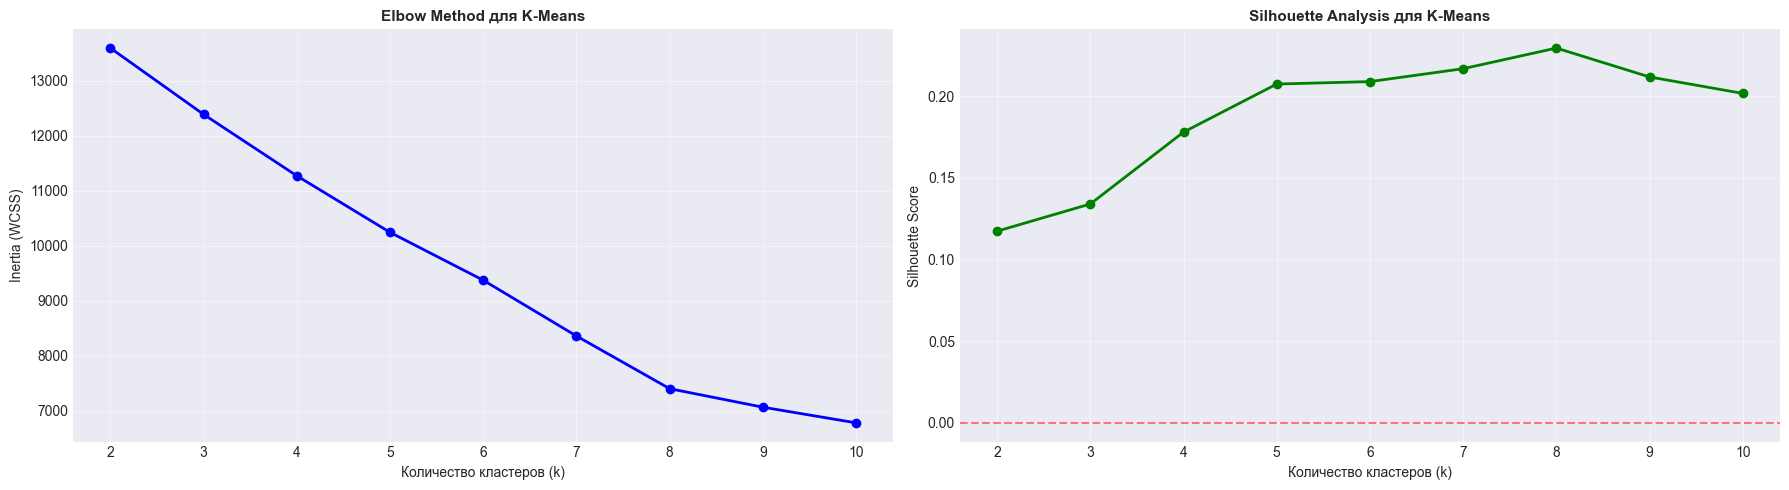

Оптимальное количество кластеров для K-Means: 8
   Silhouette Score: 0.229


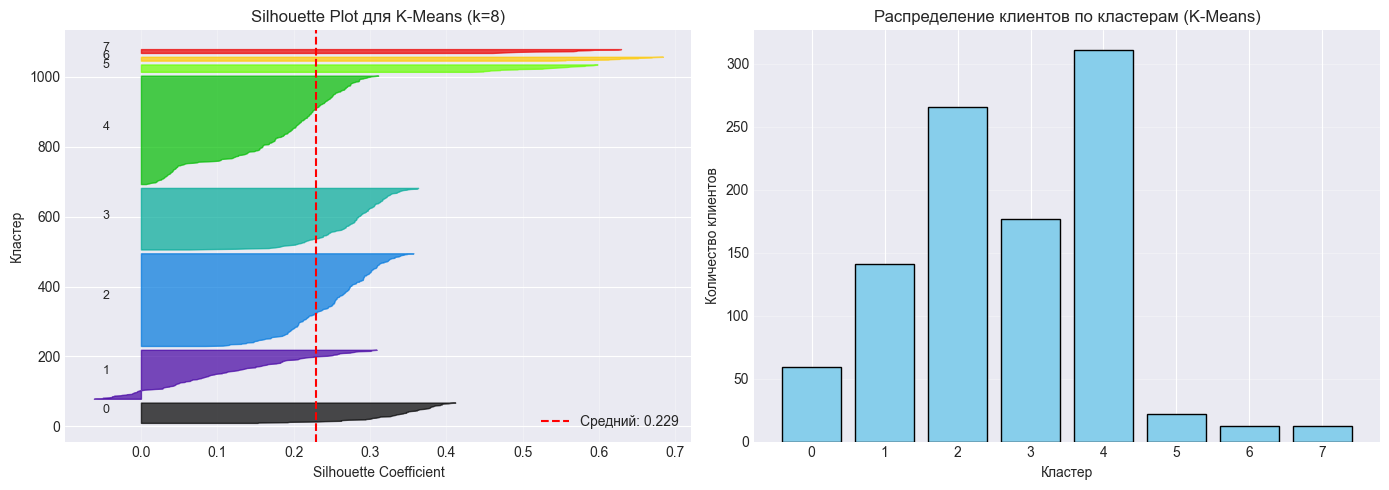

In [44]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
import umap

# 2.1 K-Means: Elbow method + Silhouette plot
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores_kmeans = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_scaled, labels))

# Визуализация: Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Elbow method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Количество кластеров (k)', fontsize=10)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=10)
axes[0].set_title('Elbow Method для K-Means', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.5)
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(k_range, silhouette_scores_kmeans, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('Количество кластеров (k)', fontsize=10)
axes[1].set_ylabel('Silhouette Score', fontsize=10)
axes[1].set_title('Silhouette Analysis для K-Means', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.5)
axes[1].set_xticks(list(k_range))
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Выбор оптимального k
optimal_k_kmeans = k_range[np.argmax(silhouette_scores_kmeans)]
print(f"Оптимальное количество кластеров для K-Means: {optimal_k_kmeans}")
print(f"   Silhouette Score: {max(silhouette_scores_kmeans):.3f}")

# Финальная кластеризация
kmeans_final = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
df_processed['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

#Silhouette plot для финального результата
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

labels_kmeans = df_processed['kmeans_cluster']
silhouette_vals = silhouette_samples(X_scaled, labels_kmeans)
y_lower = 10

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette plot by cluster
for i in range(optimal_k_kmeans):
    cluster_vals = silhouette_vals[labels_kmeans == i]
    cluster_vals.sort()
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    color = cm.nipy_spectral(float(i) / optimal_k_kmeans)
    ax[0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                        facecolor=color, edgecolor=color, alpha=0.7)
    ax[0].text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
    y_lower = y_upper + 10

sil_avg = silhouette_score(X_scaled, labels_kmeans)
ax[0].set_title(f'Silhouette Plot для K-Means (k={optimal_k_kmeans})')
ax[0].set_xlabel('Silhouette Coefficient')
ax[0].set_ylabel('Кластер')
ax[0].axvline(x=sil_avg, color="red", linestyle="--", label=f'Средний: {sil_avg:.3f}')
ax[0].legend()
ax[0].grid(axis='x', alpha=0.3)

# Распределение по кластерам
cluster_counts = labels_kmeans.value_counts().sort_index()
ax[1].bar(cluster_counts.index, cluster_counts.values, color='skyblue', edgecolor='black')
ax[1].set_xlabel('Кластер')
ax[1].set_ylabel('Количество клиентов')
ax[1].set_title('Распределение клиентов по кластерам (K-Means)')
ax[1].set_xticks(list(range(optimal_k_kmeans)))
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


HIERARCHICAL CLUSTERING: ПОДБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ


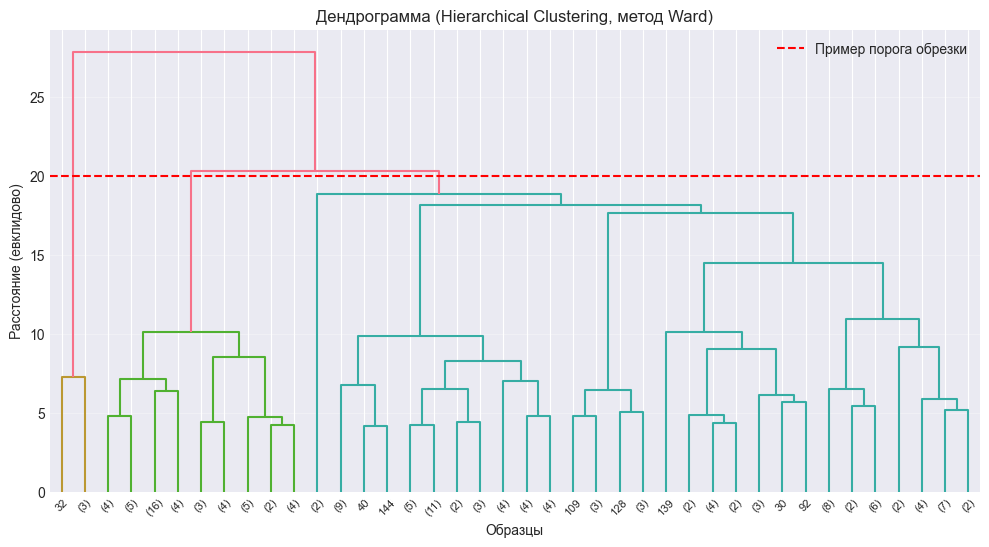

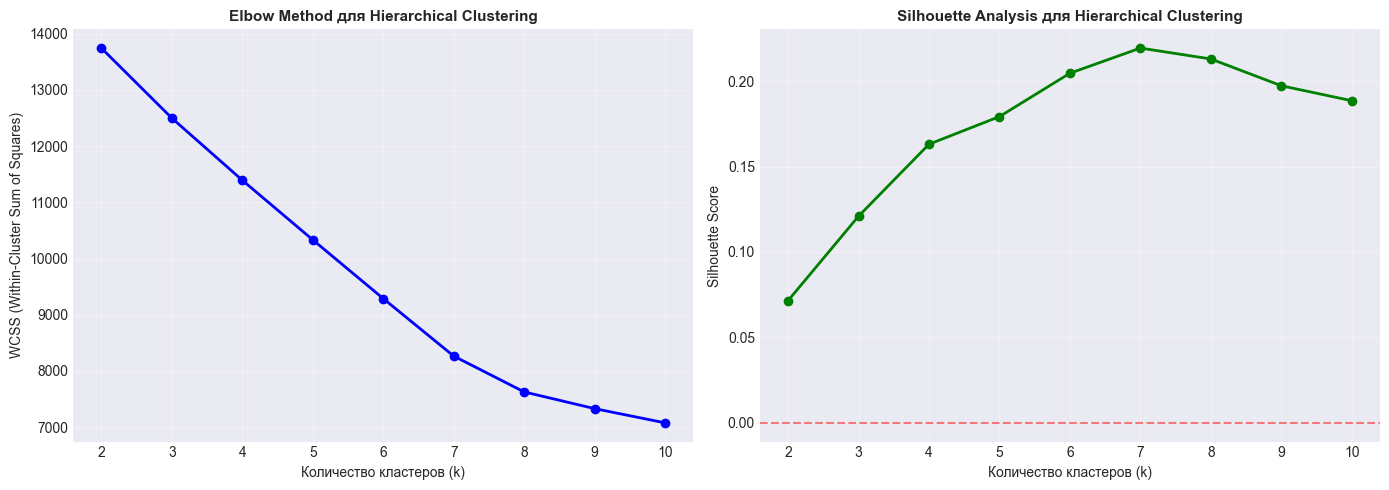

Оптимальное количество кластеров для Hierarchical: 7
Silhouette Score: 0.219


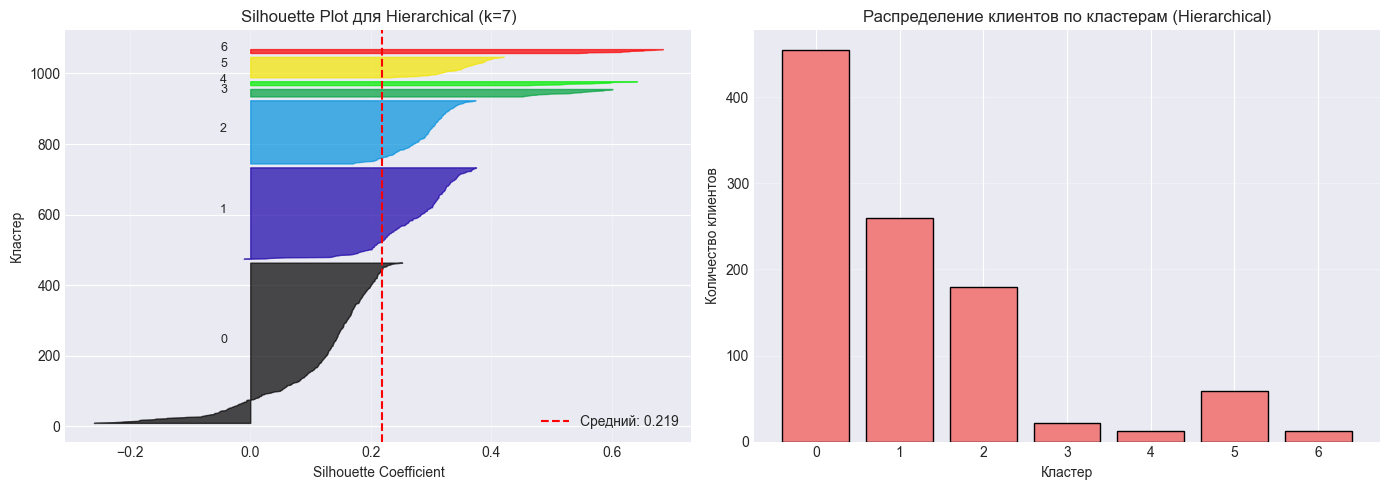

In [45]:
print("HIERARCHICAL CLUSTERING: ПОДБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ")
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Функция для расчета WCSS для иерархической кластеризации
def calculate_wcss(X, labels):
    wcss = 0
    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean(axis=0)
            wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss

# Дендрограмма (на подвыборке)
sample_idx = np.random.choice(len(X_scaled), min(150, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=40, leaf_font_size=8)
plt.title('Дендрограмма (Hierarchical Clustering, метод Ward)')
plt.xlabel('Образцы')
plt.ylabel('Расстояние (евклидово)')
plt.axhline(y=20, color='r', linestyle='--', label='Пример порога обрезки')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Подбор k: расчет WCSS и Silhouette
wcss_hier = []
silhouette_scores_hier = []
k_range = range(2, 11)

for k in k_range:
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(X_scaled)
    wcss_hier.append(calculate_wcss(X_scaled, labels))
    silhouette_scores_hier.append(silhouette_score(X_scaled, labels))

# Визуализация: Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow method (WCSS)
axes[0].plot(k_range, wcss_hier, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Количество кластеров (k)', fontsize=10)
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=10)
axes[0].set_title('Elbow Method для Hierarchical Clustering', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(k_range, silhouette_scores_hier, 'go-', linewidth=2, markersize=6)
axes[1].set_xlabel('Количество кластеров (k)', fontsize=10)
axes[1].set_ylabel('Silhouette Score', fontsize=10)
axes[1].set_title('Silhouette Analysis для Hierarchical Clustering', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(k_range))
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Выбор оптимального k
optimal_k_hier = k_range[np.argmax(silhouette_scores_hier)]
print(f"Оптимальное количество кластеров для Hierarchical: {optimal_k_hier}")
print(f"Silhouette Score: {max(silhouette_scores_hier):.3f}")

# Финальная кластеризация
hier_final = AgglomerativeClustering(n_clusters=optimal_k_hier, linkage='ward')
df_processed['hier_cluster'] = hier_final.fit_predict(X_scaled)

#Silhouette plot для финального результата
labels_hier = df_processed['hier_cluster']
silhouette_vals_hier = silhouette_samples(X_scaled, labels_hier)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
y_lower = 10

for i in range(optimal_k_hier):
    cluster_vals = silhouette_vals_hier[labels_hier == i]
    cluster_vals.sort()
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    color = cm.nipy_spectral(float(i) / optimal_k_hier)
    ax[0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                        facecolor=color, edgecolor=color, alpha=0.7)
    ax[0].text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
    y_lower = y_upper + 10

sil_avg_hier = silhouette_score(X_scaled, labels_hier)
ax[0].set_title(f'Silhouette Plot для Hierarchical (k={optimal_k_hier})')
ax[0].set_xlabel('Silhouette Coefficient')
ax[0].set_ylabel('Кластер')
ax[0].axvline(x=sil_avg_hier, color="red", linestyle="--", label=f'Средний: {sil_avg_hier:.3f}')
ax[0].legend()
ax[0].grid(axis='x', alpha=0.3)

# Распределение по кластерам
cluster_counts_hier = pd.Series(labels_hier).value_counts().sort_index()
ax[1].bar(cluster_counts_hier.index, cluster_counts_hier.values, color='lightcoral', edgecolor='black')
ax[1].set_xlabel('Кластер')
ax[1].set_ylabel('Количество клиентов')
ax[1].set_title('Распределение клиентов по кластерам (Hierarchical)')
ax[1].set_xticks(list(range(optimal_k_hier)))
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

DBSCAN: ПОДБОР ПАРАМЕТРОВ (eps, min_samples)
K-distance graph для подбора eps:


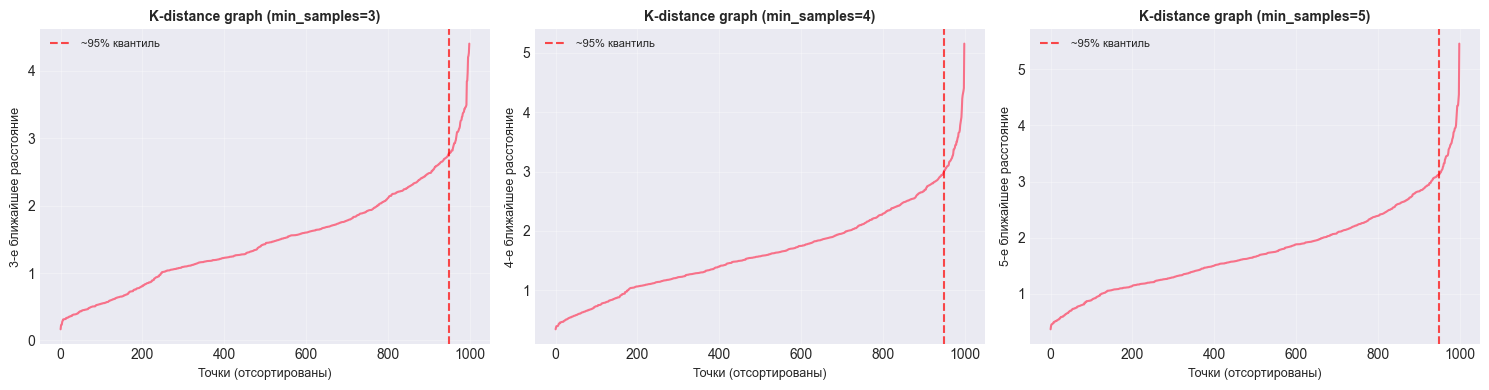

Grid search по параметрам DBSCAN:


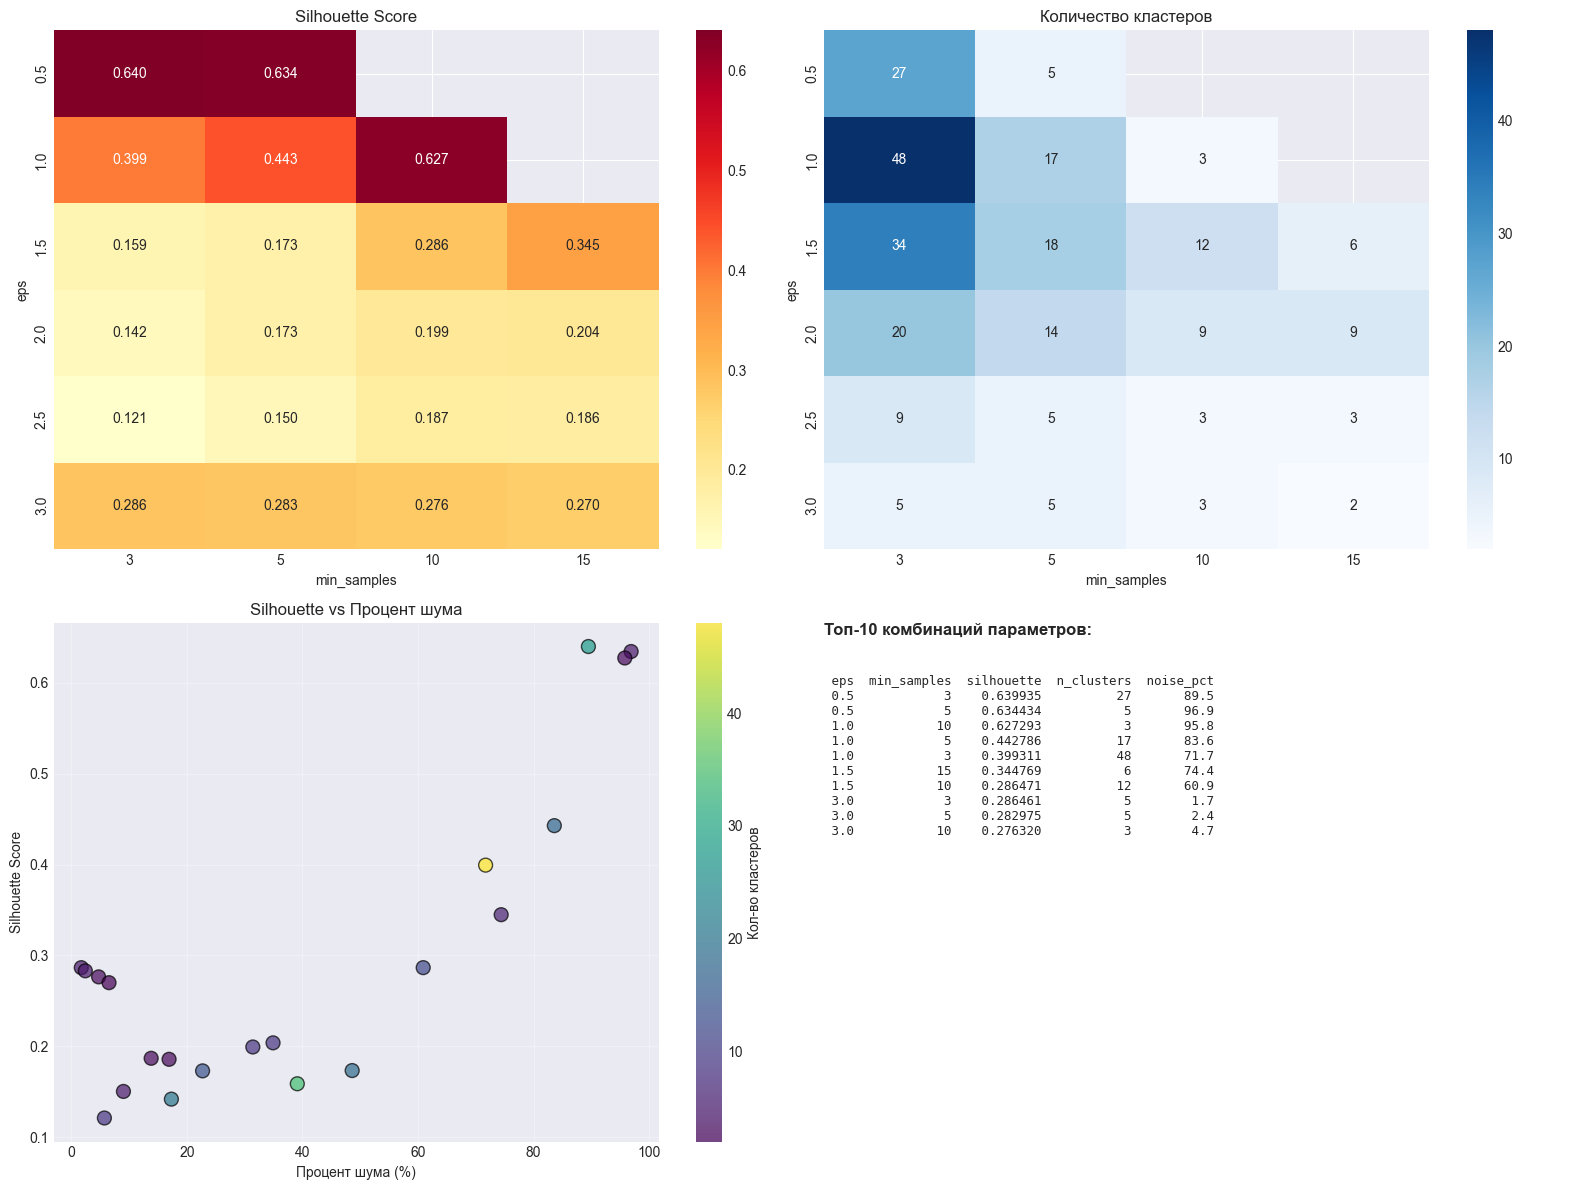

Лучшие параметры: eps=0.5, min_samples=3
Silhouette Score: 0.640
Результаты DBSCAN:
Количество кластеров: 27
Шумовые точки: 895 (89.5%)
Распределение:
dbscan_cluster
-1     895
 0       3
 1       3
 2       8
 3       3
 4       9
 5       3
 6       3
 7       9
 8       5
 9       3
 10      3
 11      3
 12      4
 13      3
 14      4
 15      3
 16      3
 17      3
 18      3
 19      5
 20      4
 21      3
 22      3
 23      3
 24      3
 25      3
 26      3
Name: count, dtype: int64


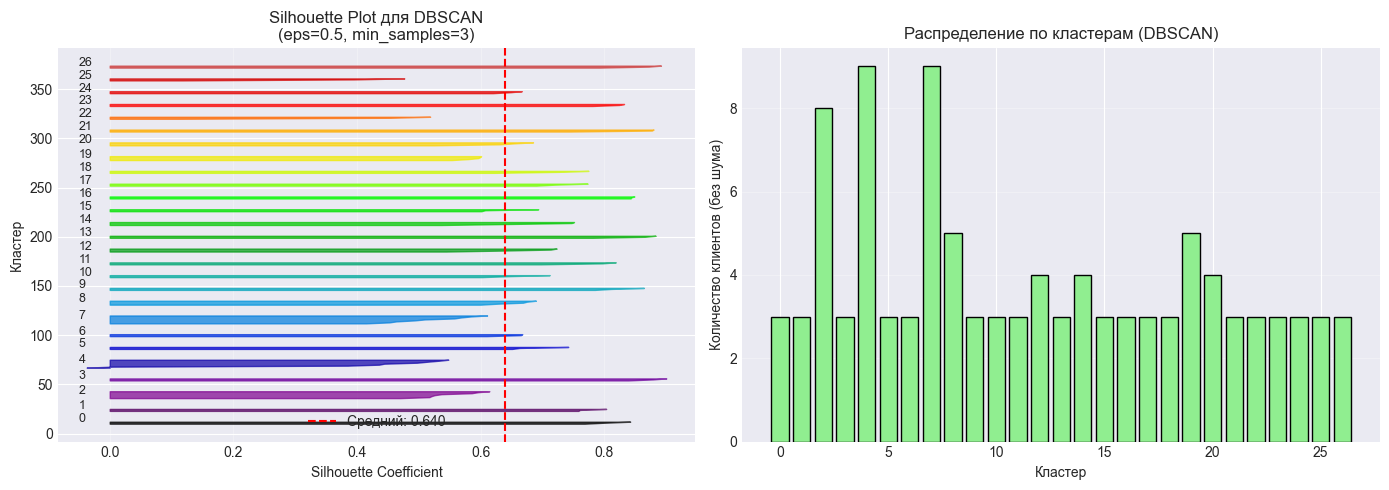

In [46]:
#2.3 DBSCAN: K-distance graph (Elbow-like) + Silhouette analysis
print("DBSCAN: ПОДБОР ПАРАМЕТРОВ (eps, min_samples)")
from sklearn.neighbors import NearestNeighbors

print("K-distance graph для подбора eps:")

k_values = [3, 4, 5]  # проверяем несколько значений min_samples
fig, axes = plt.subplots(1, len(k_values), figsize=(15, 4))
if len(k_values) == 1:
    axes = [axes]

for idx, k in enumerate(k_values):
    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs_fit = nbrs.fit(X_scaled)
    distances, _ = nbrs_fit.kneighbors(X_scaled)
    k_distances = np.sort(distances[:, k-1])

    axes[idx].plot(k_distances)
    axes[idx].set_xlabel('Точки (отсортированы)', fontsize=9)
    axes[idx].set_ylabel(f'{k}-е ближайшее расстояние', fontsize=9)
    axes[idx].set_title(f'K-distance graph (min_samples={k})', fontsize=10, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    # Отмечаем "локоть" визуально
    axes[idx].axvline(x=len(k_distances)*0.95, color='r', linestyle='--', alpha=0.7, label='~95% квантиль')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()


print("Grid search по параметрам DBSCAN:")

best_score = -1
best_params = None
dbscan_results = []

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # Исключаем шум (-1) из расчета метрик
        mask = labels != -1
        n_clusters = len(np.unique(labels[mask]))
        noise_pct = (1 - mask.sum()/len(labels)) * 100

        if mask.sum() > 1 and n_clusters > 1:
            sil_score = silhouette_score(X_scaled[mask], labels[mask])
            dbscan_results.append({
                'eps': eps,
                'min_samples': min_samples,
                'silhouette': sil_score,
                'n_clusters': n_clusters,
                'noise_pct': noise_pct
            })
            if sil_score > best_score:
                best_score = sil_score
                best_params = (eps, min_samples)

results_df = pd.DataFrame(dbscan_results)

# Визуализация результатов поиска
if not results_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Heatmap Silhouette Score
    pivot_sil = results_df.pivot(index='eps', columns='min_samples', values='silhouette')
    sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,0])
    axes[0,0].set_title('Silhouette Score')
    axes[0,0].set_xlabel('min_samples')
    axes[0,0].set_ylabel('eps')

    # 2. Heatmap количества кластеров
    pivot_clust = results_df.pivot(index='eps', columns='min_samples', values='n_clusters')
    sns.heatmap(pivot_clust, annot=True, fmt='.0f', cmap='Blues', ax=axes[0,1])
    axes[0,1].set_title('Количество кластеров')
    axes[0,1].set_xlabel('min_samples')
    axes[0,1].set_ylabel('eps')

    # 3. Scatter: Silhouette vs Noise %
    scatter = axes[1,0].scatter(results_df['noise_pct'], results_df['silhouette'],
                               c=results_df['n_clusters'], s=100, cmap='viridis', alpha=0.7, edgecolors='black')
    axes[1,0].set_xlabel('Процент шума (%)')
    axes[1,0].set_ylabel('Silhouette Score')
    axes[1,0].set_title('Silhouette vs Процент шума')
    axes[1,0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1,0], label='Кол-во кластеров')

    # 4. Лучшие комбинации
    top_results = results_df.nlargest(10, 'silhouette')[['eps', 'min_samples', 'silhouette', 'n_clusters', 'noise_pct']]
    axes[1,1].axis('off')
    axes[1,1].text(0, 1, 'Топ-10 комбинаций параметров:', fontsize=12, fontweight='bold', va='top')
    axes[1,1].text(0, 0.9, top_results.to_string(index=False), fontsize=9, va='top', family='monospace')

    plt.tight_layout()
    plt.show()

    print(f"Лучшие параметры: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"Silhouette Score: {best_score:.3f}")
else:
    print("Не найдено подходящих комбинаций параметров")
    best_params = (1.5, 5)

#Финальная DBSCAN кластеризация
eps_opt, min_samples_opt = best_params
dbscan_final = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
df_processed['dbscan_cluster'] = dbscan_final.fit_predict(X_scaled)

# Статистика
labels_dbscan = df_processed['dbscan_cluster']
n_noise = (labels_dbscan == -1).sum()
n_clusters_dbscan = len(np.unique(labels_dbscan[labels_dbscan != -1]))
print(f"Результаты DBSCAN:")
print(f"Количество кластеров: {n_clusters_dbscan}")
print(f"Шумовые точки: {n_noise} ({n_noise/len(df_processed)*100:.1f}%)")
print(f"Распределение:\n{labels_dbscan.value_counts().sort_index()}")

# Silhouette plot для DBSCAN
mask_non_noise = labels_dbscan != -1
if mask_non_noise.sum() > 1 and n_clusters_dbscan > 1:
    silhouette_vals_dbscan = silhouette_samples(X_scaled[mask_non_noise], labels_dbscan[mask_non_noise])
    unique_clusters = np.unique(labels_dbscan[mask_non_noise])

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    y_lower = 10

    for i, cluster_id in enumerate(unique_clusters):
        if cluster_id == -1:
            continue
        cluster_vals = silhouette_vals_dbscan[labels_dbscan[mask_non_noise] == cluster_id]
        cluster_vals.sort()
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        color = cm.nipy_spectral(float(i) / len(unique_clusters))
        ax[0].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                            facecolor=color, edgecolor=color, alpha=0.7)
        ax[0].text(-0.05, y_lower + 0.5 * size, str(int(cluster_id)), fontsize=9)
        y_lower = y_upper + 10

    sil_avg_dbscan = silhouette_score(X_scaled[mask_non_noise], labels_dbscan[mask_non_noise])
    ax[0].set_title(f'Silhouette Plot для DBSCAN\n(eps={eps_opt}, min_samples={min_samples_opt})')
    ax[0].set_xlabel('Silhouette Coefficient')
    ax[0].set_ylabel('Кластер')
    ax[0].axvline(x=sil_avg_dbscan, color="red", linestyle="--", label=f'Средний: {sil_avg_dbscan:.3f}')
    ax[0].legend()
    ax[0].grid(axis='x', alpha=0.3)

    # Распределение (без шума)
    cluster_counts_dbscan = pd.Series(labels_dbscan[mask_non_noise]).value_counts().sort_index()
    ax[1].bar(cluster_counts_dbscan.index, cluster_counts_dbscan.values, color='lightgreen', edgecolor='black')
    ax[1].set_xlabel('Кластер')
    ax[1].set_ylabel('Количество клиентов (без шума)')
    ax[1].set_title('Распределение по кластерам (DBSCAN)')
    ax[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для построения Silhouette plot (много шума или мало кластеров)")

ВИЗУАЛИЗАЦИЯ: КЛАСТЕРИЗАЦИЯ × УМЕНЬШЕНИЕ РАЗМЕРНОСТИ
Применяем методы уменьшения размерности...
PCA: объяснённая дисперсия = 0.230
UMAP: преобразование завершено
t-SNE: преобразование завершено


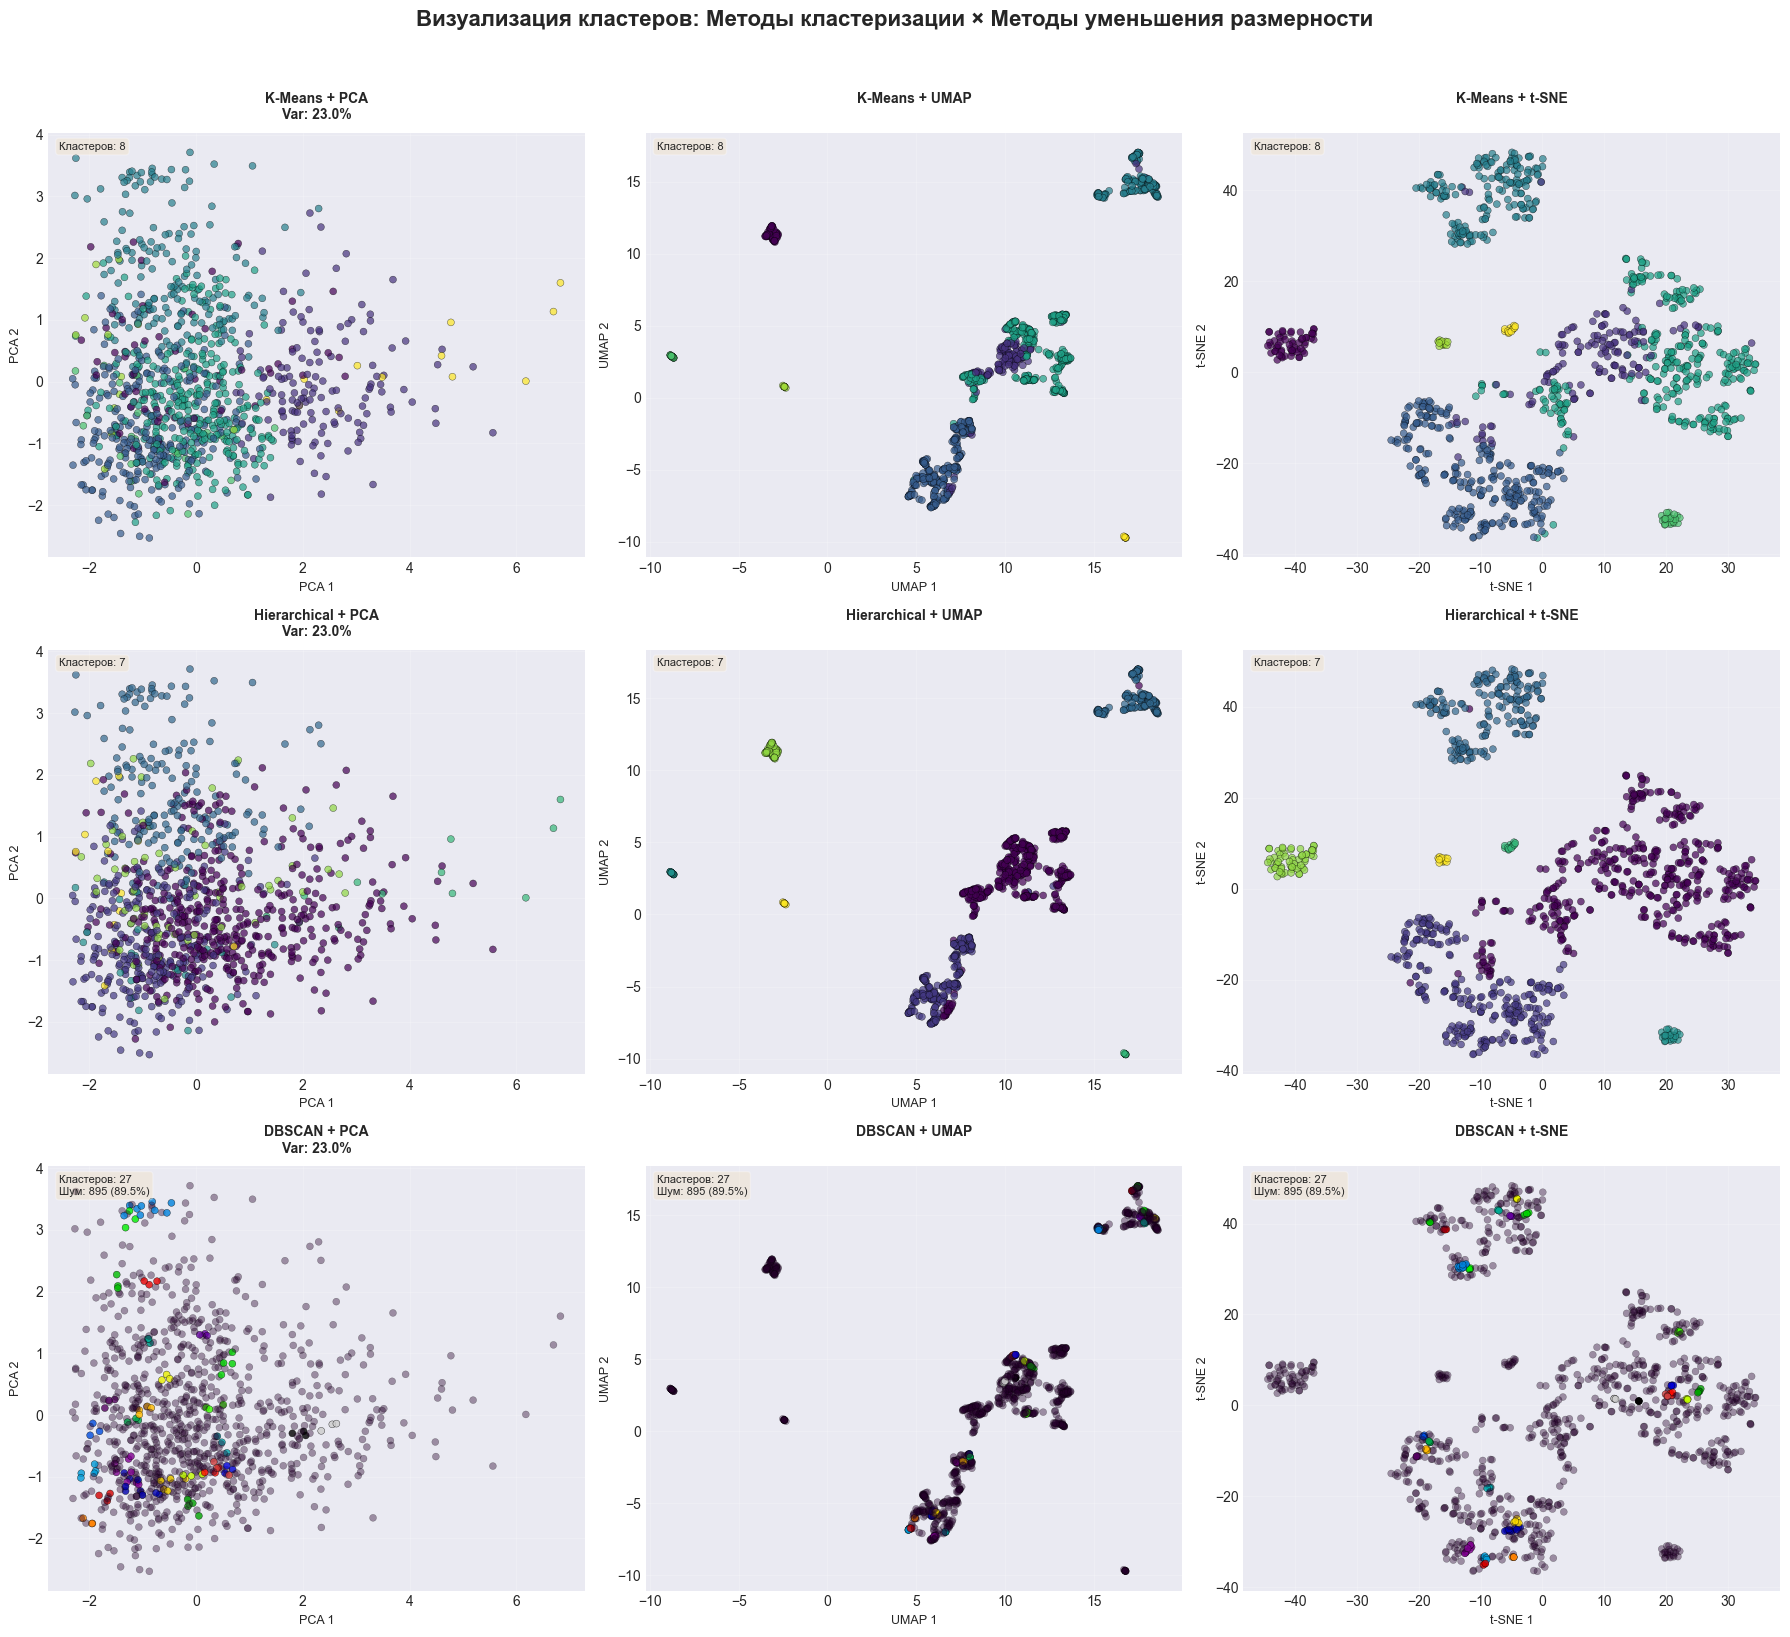

Сравнительная визуализация по методам кластеризации...


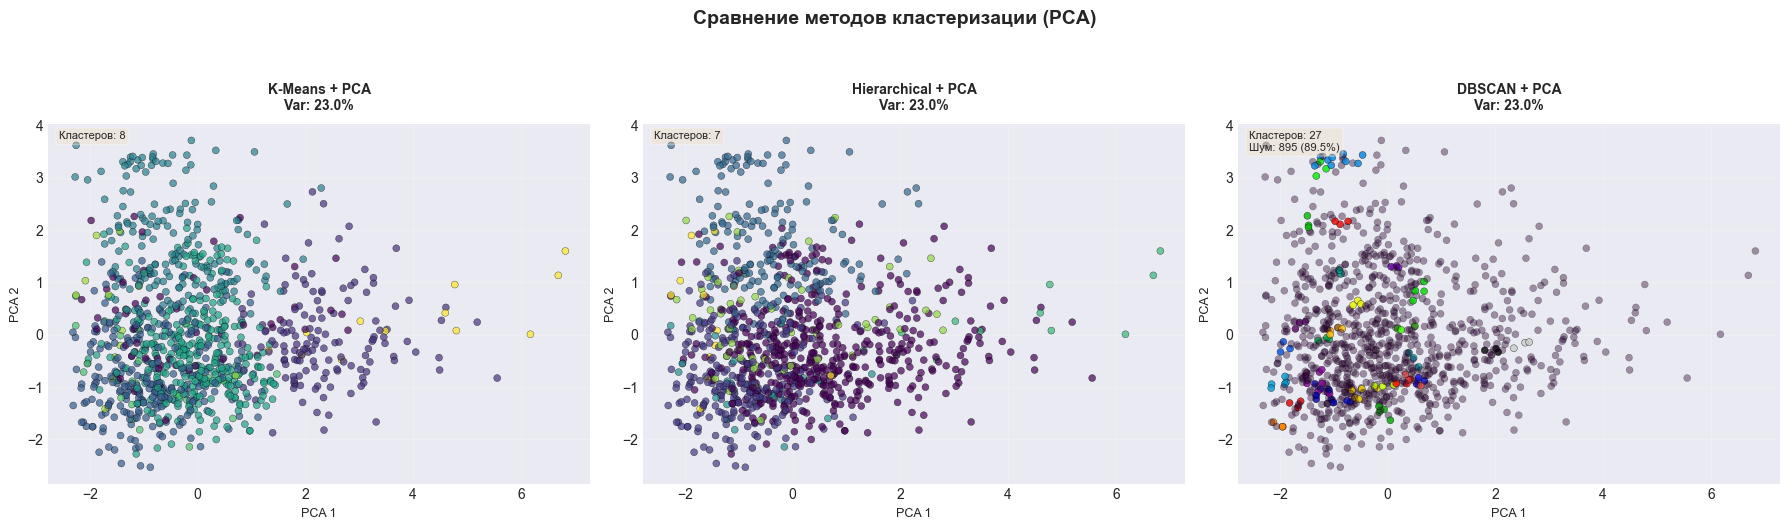

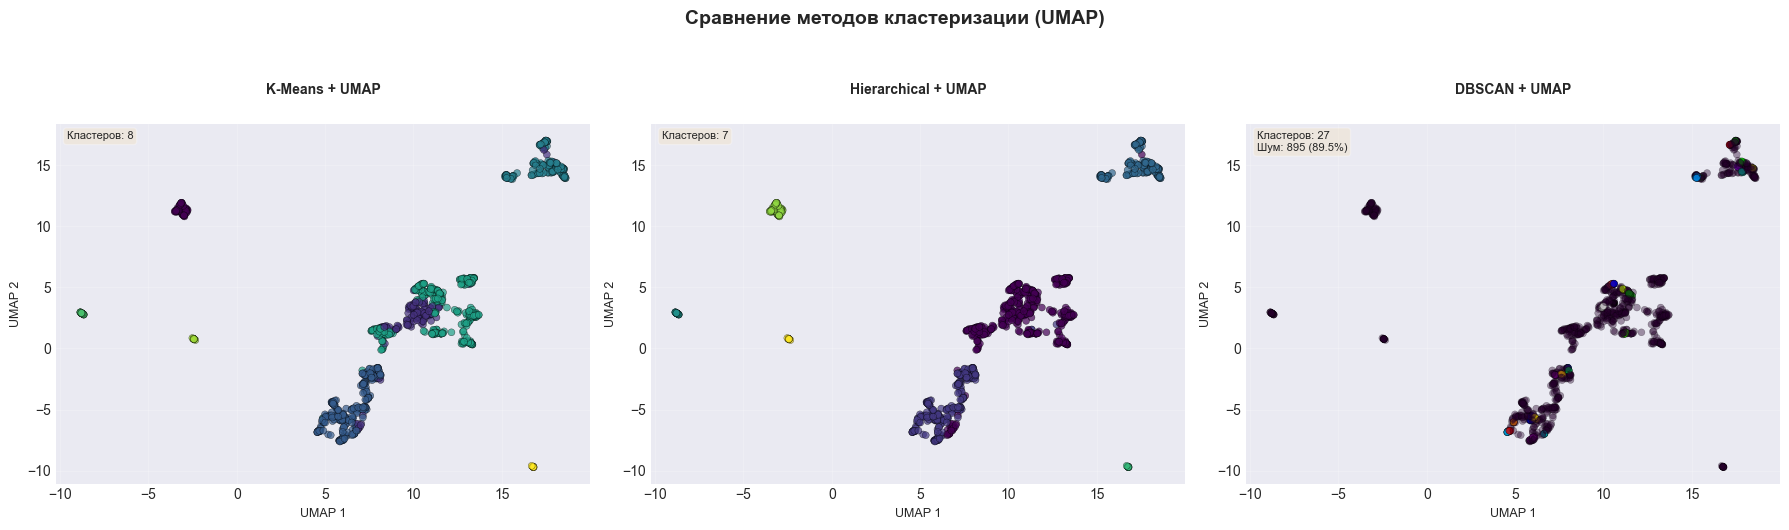

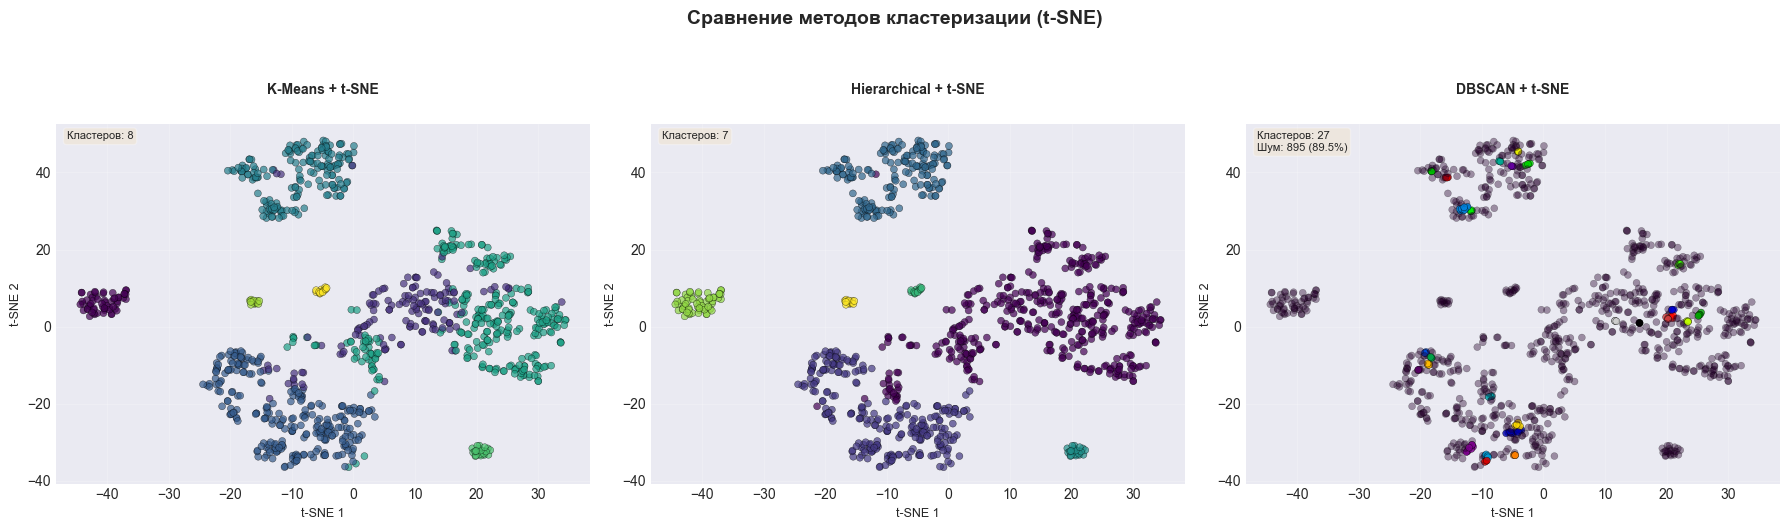

In [47]:
# 2.4 ВИЗУАЛИЗАЦИЯ: Все методы кластеризации × Все методы уменьшения размерности
print("ВИЗУАЛИЗАЦИЯ: КЛАСТЕРИЗАЦИЯ × УМЕНЬШЕНИЕ РАЗМЕРНОСТИ")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Шаг 1: Применение всех методов уменьшения размерности к масштабированным данным

print("Применяем методы уменьшения размерности...")

# 1. PCA (линейный метод)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: объяснённая дисперсия = {pca.explained_variance_ratio_.sum():.3f}")

# 2. UMAP (нелинейный, сохраняет локальную и глобальную структуру)
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X_scaled)
print(f"UMAP: преобразование завершено")

# 3. t-SNE (нелинейный, оптимизирован для визуализации)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=1000, init='pca')
X_tsne = tsne.fit_transform(X_scaled)
print(f"t-SNE: преобразование завершено")

# Шаг 2: Функция для построения визуализации кластеров

def plot_clusters(X_reduced, labels, method_name, reduction_name, ax, title_suffix=""):
    """
    Вспомогательная функция для визуализации кластеров на 2D плоскости.

    Параметры:
    - X_reduced: данные после уменьшения размерности (n_samples × 2)
    - labels: метки кластеров
    - method_name: название метода кластеризации
    - reduction_name: название метода уменьшения размерности
    - ax: ось matplotlib для рисования
    - title_suffix: дополнительный текст для заголовка
    """
    # Обработка шума для DBSCAN
    if method_name == 'DBSCAN':
        # Шумовые точки (-1) отображаем серым
        colors = np.where(labels == -1, 0.5, labels)
        cmap = 'nipy_spectral'
        alpha = np.where(labels == -1, 0.4, 0.8)
    else:
        colors = labels
        cmap = 'viridis'
        alpha = 0.7

    scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1],
                         c=colors, cmap=cmap, s=25, alpha=alpha,
                         edgecolors='black', linewidth=0.3)

    ax.set_xlabel(f'{reduction_name} 1', fontsize=9)
    ax.set_ylabel(f'{reduction_name} 2', fontsize=9)
    ax.set_title(f'{method_name} + {reduction_name}\n{title_suffix}',
                 fontsize=10, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.2)

    # Добавляем легенду с количеством кластеров
    n_clusters = len(np.unique(labels[labels != -1])) if method_name == 'DBSCAN' else len(np.unique(labels))
    n_noise = (labels == -1).sum() if method_name == 'DBSCAN' else 0
    info_text = f"Кластеров: {n_clusters}" + (f"\nШум: {n_noise} ({n_noise/len(labels)*100:.1f}%)" if n_noise > 0 else "")
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    return scatter

# Шаг 3: Визуализация для каждого метода кластеризации

clustering_methods = [
    ('K-Means', df_processed['kmeans_cluster'].values),
    ('Hierarchical', df_processed['hier_cluster'].values),
    ('DBSCAN', df_processed['dbscan_cluster'].values)
]

reduction_methods = [
    ('PCA', X_pca, f"Var: {pca.explained_variance_ratio_.sum():.1%}"),
    ('UMAP', X_umap, ""),
    ('t-SNE', X_tsne, "")
]

# Создаём сетку 3×3: строки = методы кластеризации, столбцы = методы уменьшения размерности
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for row_idx, (cluster_name, cluster_labels) in enumerate(clustering_methods):
    for col_idx, (reduct_name, X_reduced, title_info) in enumerate(reduction_methods):
        ax = axes[row_idx, col_idx]
        plot_clusters(X_reduced, cluster_labels, cluster_name, reduct_name, ax, title_info)

# Общий заголовок
fig.suptitle('Визуализация кластеров: Методы кластеризации × Методы уменьшения размерности',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Шаг 4: Сравнительная визуализация: один метод уменьшения размерности × все кластеры

print("Сравнительная визуализация по методам кластеризации...")

for reduct_name, X_reduced, title_info in reduction_methods:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, (cluster_name, cluster_labels) in enumerate(clustering_methods):
        ax = axes[idx]
        plot_clusters(X_reduced, cluster_labels, cluster_name, reduct_name, ax, title_info)

    fig.suptitle(f'Сравнение методов кластеризации ({reduct_name})',
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


ТАБЛИЦА МЕТРИК: Elbow Method + Silhouette Plot
K-Means: Inertia=7,404, Silhouette=0.229
Hierarchical: WCSS=8,264, Silhouette=0.219
DBSCAN: eps=0.5, Silhouette=0.640, Шум=895 точек
ИТОГОВАЯ ТАБЛИЦА МЕТРИК (Elbow + Silhouette)


,Method,N_Clusters,Elbow_Metric,Silhouette_Score,Noise_Points
0,K-Means,8,"Inertia (WCSS) = 7,404",0.229,NaN
1,Hierarchical,7,"WCSS = 8,264",0.219,NaN
2,DBSCAN,27,eps (K-distance) = 0.5,0.640,895.0


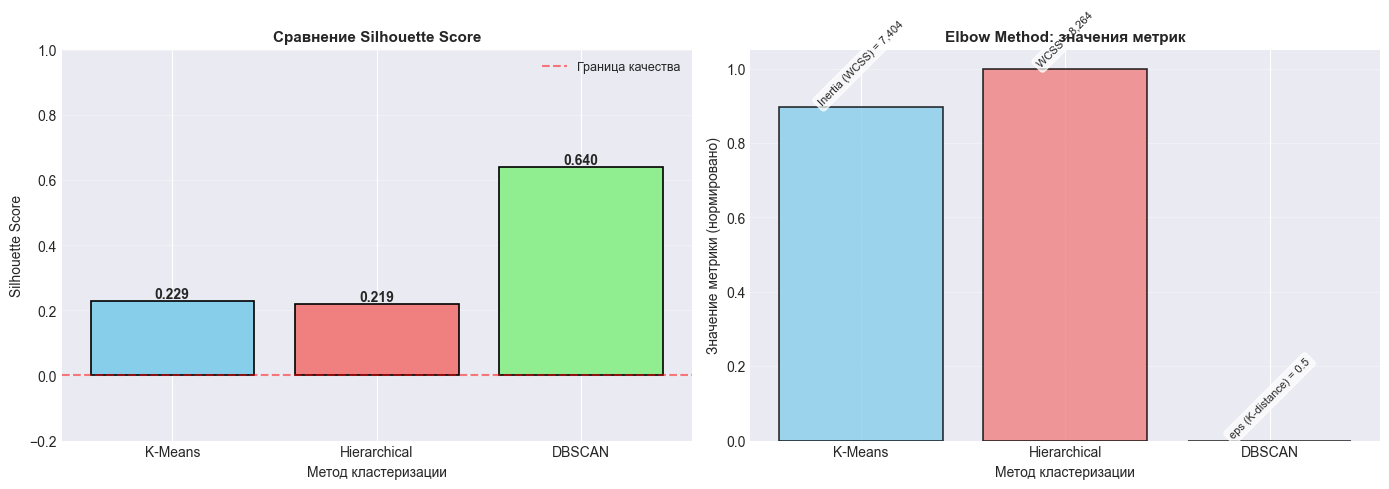

Детальные Silhouette Plots для каждого метода:


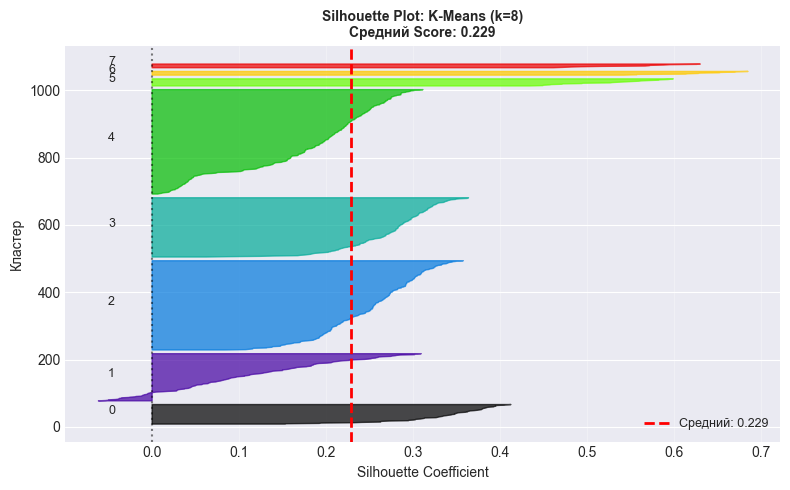

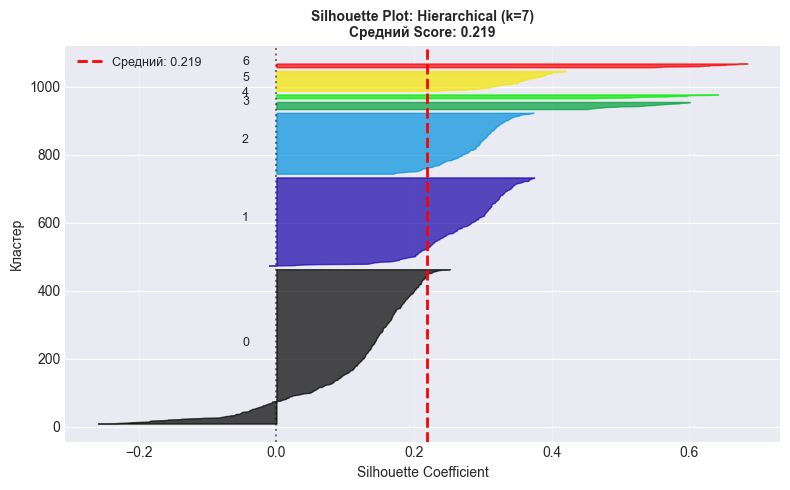

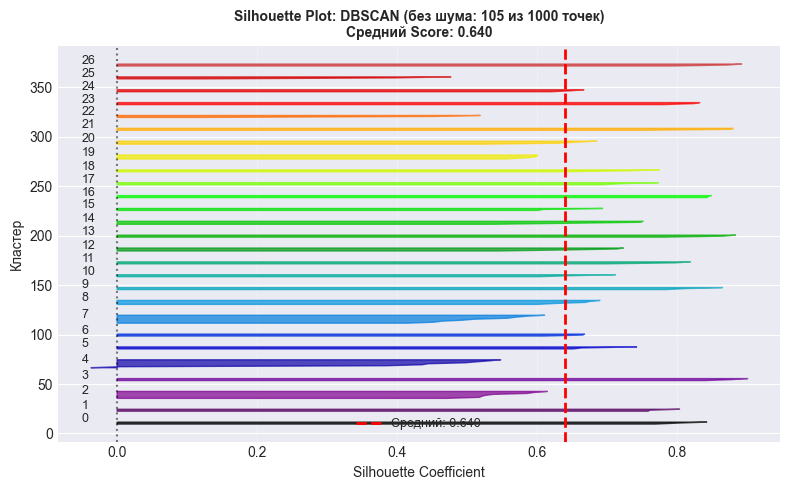

Таблица метрик обновлена: только Elbow method и Silhouette plot


In [48]:
# Шаг 5: ТАБЛИЦА МЕТРИК КАЧЕСТВА (только Elbow method и Silhouette plot)
print("ТАБЛИЦА МЕТРИК: Elbow Method + Silhouette Plot")
from sklearn.metrics import silhouette_score, silhouette_samples

# Список для сбора результатов
results_table = []

# K-Means: Inertia (Elbow) + Silhouette Score

labels_kmeans = df_processed['kmeans_cluster'].values
kmeans_inertia = kmeans_final.inertia_  # WCSS из финальной модели
kmeans_silhouette = silhouette_score(X_scaled, labels_kmeans)

results_table.append({
    'Method': 'K-Means',
    'Elbow_Metric': f'Inertia (WCSS) = {kmeans_inertia:,.0f}',
    'Elbow_Value': kmeans_inertia,  # числовое значение для сортировки
    'Silhouette_Score': kmeans_silhouette,
    'N_Clusters': len(np.unique(labels_kmeans))
})

print(f"K-Means: Inertia={kmeans_inertia:,.0f}, Silhouette={kmeans_silhouette:.3f}")
# Hierarchical: WCSS (Elbow) + Silhouette Score

labels_hier = df_processed['hier_cluster'].values

# Функция расчета WCSS для иерархической кластеризации
def calculate_wcss(X, labels):
    wcss = 0
    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean(axis=0)
            wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss

hier_wcss = calculate_wcss(X_scaled, labels_hier)
hier_silhouette = silhouette_score(X_scaled, labels_hier)

results_table.append({
    'Method': 'Hierarchical',
    'Elbow_Metric': f'WCSS = {hier_wcss:,.0f}',
    'Elbow_Value': hier_wcss,
    'Silhouette_Score': hier_silhouette,
    'N_Clusters': len(np.unique(labels_hier))
})

print(f"Hierarchical: WCSS={hier_wcss:,.0f}, Silhouette={hier_silhouette:.3f}")

# DBSCAN: K-distance (Elbow-like) + Silhouette Score (без шума)

labels_dbscan = df_processed['dbscan_cluster'].values

# Для DBSCAN: исключаем шум (-1) из расчёта метрик
mask_non_noise = labels_dbscan != -1
n_noise = (~mask_non_noise).sum()

if mask_non_noise.sum() > 1 and len(np.unique(labels_dbscan[mask_non_noise])) > 1:
    dbscan_silhouette = silhouette_score(X_scaled[mask_non_noise], labels_dbscan[mask_non_noise])
    # Для DBSCAN Elbow-метрика — это оптимальное значение eps
    dbscan_eps = best_params[0] if 'best_params' in dir() else 'N/A'

    results_table.append({
        'Method': 'DBSCAN',
        'Elbow_Metric': f'eps (K-distance) = {dbscan_eps}',
        'Elbow_Value': dbscan_eps if isinstance(dbscan_eps, (int, float)) else 999999,
        'Silhouette_Score': dbscan_silhouette,
        'N_Clusters': len(np.unique(labels_dbscan[mask_non_noise])),
        'Noise_Points': int(n_noise)
    })
    print(f"DBSCAN: eps={dbscan_eps}, Silhouette={dbscan_silhouette:.3f}, Шум={n_noise} точек")
else:
    print("DBSCAN: недостаточно кластеров для расчёта Silhouette Score")

# Формирование и отображение итоговой таблицы
results_df = pd.DataFrame(results_table)

# Отображаем только нужные колонки
display_cols = ['Method', 'N_Clusters', 'Elbow_Metric', 'Silhouette_Score']
if 'Noise_Points' in results_df.columns:
    display_cols.append('Noise_Points')

print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК (Elbow + Silhouette)")
display(results_df[display_cols].round(3))

# Визуализация: Silhouette Score по методам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar plot: Silhouette Score
colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = axes[0].bar(results_df['Method'], results_df['Silhouette_Score'],
                   color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Метод кластеризации', fontsize=10)
axes[0].set_ylabel('Silhouette Score', fontsize=10)
axes[0].set_title('Сравнение Silhouette Score', fontsize=11, fontweight='bold')
axes[0].set_ylim(-0.2, 1.0)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Граница качества')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, score in zip(bars, results_df['Silhouette_Score']):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.3f}', ha='center', va='bottom' if score >= 0 else 'top',
                fontsize=10, fontweight='bold')

# 2. Elbow values (нормированные для сравнения)
axes[1].set_xlabel('Метод кластеризации', fontsize=10)
axes[1].set_ylabel('Значение метрики (нормировано)', fontsize=10)
axes[1].set_title('Elbow Method: значения метрик', fontsize=11, fontweight='bold')

# Нормируем Elbow_Value для визуализации (т.к. масштабы разные)
elbow_vals = results_df['Elbow_Value'].astype(float).replace(999999, np.nan)
elbow_normalized = (elbow_vals - elbow_vals.min()) / (elbow_vals.max() - elbow_vals.min())

bars2 = axes[1].bar(results_df['Method'], elbow_normalized,
                    color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)
axes[1].grid(axis='y', alpha=0.3)

# Подписи с оригинальными значениями
for bar, orig_val, norm_val in zip(bars2, results_df['Elbow_Metric'], elbow_normalized):
    if not np.isnan(norm_val):
        axes[1].text(bar.get_x() + bar.get_width()/2., norm_val,
                    f'{orig_val}', ha='center', va='bottom',
                    fontsize=8, rotation=45, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# Детальный Silhouette Plot для каждого метода (опционально)
print("Детальные Silhouette Plots для каждого метода:")

for idx, (method_name, labels) in enumerate([
    ('K-Means', labels_kmeans),
    ('Hierarchical', labels_hier),
    ('DBSCAN', labels_dbscan)
]):
    # Для DBSCAN исключаем шум
    if method_name == 'DBSCAN':
        mask = labels != -1
        if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
            continue
        eval_labels = labels[mask]
        eval_X = X_scaled[mask]
        plot_title = f'{method_name} (без шума: {mask.sum()} из {len(labels)} точек)'
    else:
        eval_labels = labels
        eval_X = X_scaled
        n_clust = len(np.unique(eval_labels))
        plot_title = f'{method_name} (k={n_clust})'

    sil_avg = silhouette_score(eval_X, eval_labels)
    sil_vals = silhouette_samples(eval_X, eval_labels)
    unique_clusters = np.unique(eval_labels)

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    y_lower = 10

    for i, cluster_id in enumerate(unique_clusters):
        if cluster_id == -1:
            continue
        cluster_vals = sil_vals[eval_labels == cluster_id]
        cluster_vals.sort()
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        color = plt.cm.nipy_spectral(float(i) / len(unique_clusters))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                        facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(int(cluster_id)), fontsize=9)
        y_lower = y_upper + 10

    ax.set_title(f'Silhouette Plot: {plot_title}\nСредний Score: {sil_avg:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Кластер')
    ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=2, label=f'Средний: {sil_avg:.3f}')
    ax.axvline(x=0, color="black", linestyle=":", alpha=0.5)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Таблица метрик обновлена: только Elbow method и Silhouette plot")

In [49]:
# ЧАСТЬ 3: Интерпретация кластеров
# 3.1 Расчет средних значений признаков по кластерам (K-Means)

# Выбираем исходные (немасштабированные) признаки для интерпретации
interpret_cols = ['Age', 'Job', 'Credit amount', 'Duration',
                  'Sex_encoded', 'Housing_encoded', 'Saving_encoded', 'Checking_encoded']

cluster_stats = df_processed.groupby('kmeans_cluster')[interpret_cols].mean().round(2)
display(cluster_stats)

# Количество клиентов в каждом кластере
cluster_counts = df_processed['kmeans_cluster'].value_counts().sort_index()
print(f"\nКоличество клиентов в кластерах:\n{cluster_counts}")


,Age,Job,Credit amount,Duration,Sex_encoded,Housing_encoded,Saving_encoded,Checking_encoded
kmeans_cluster,,,,,,,,
0,38.29,1.85,2879.20,19.68,0.59,0.59,1.03,1.00
1,37.74,2.37,7924.57,37.74,0.81,0.55,0.94,1.01
2,34.99,1.86,2141.89,18.39,0.70,0.33,1.18,1.00
3,32.43,1.91,2897.70,18.76,0.59,0.60,1.26,1.01
4,35.95,1.75,2330.80,16.71,0.70,0.47,1.30,0.97
5,38.55,1.50,2728.09,19.09,0.77,0.32,1.41,1.05
6,34.25,1.75,1498.00,16.83,0.50,0.33,1.17,1.00
7,39.92,2.50,8209.33,32.33,0.75,0.33,1.00,1.50



Количество клиентов в кластерах:
kmeans_cluster
0     59
1    141
2    266
3    177
4    311
5     22
6     12
7     12
Name: count, dtype: int64


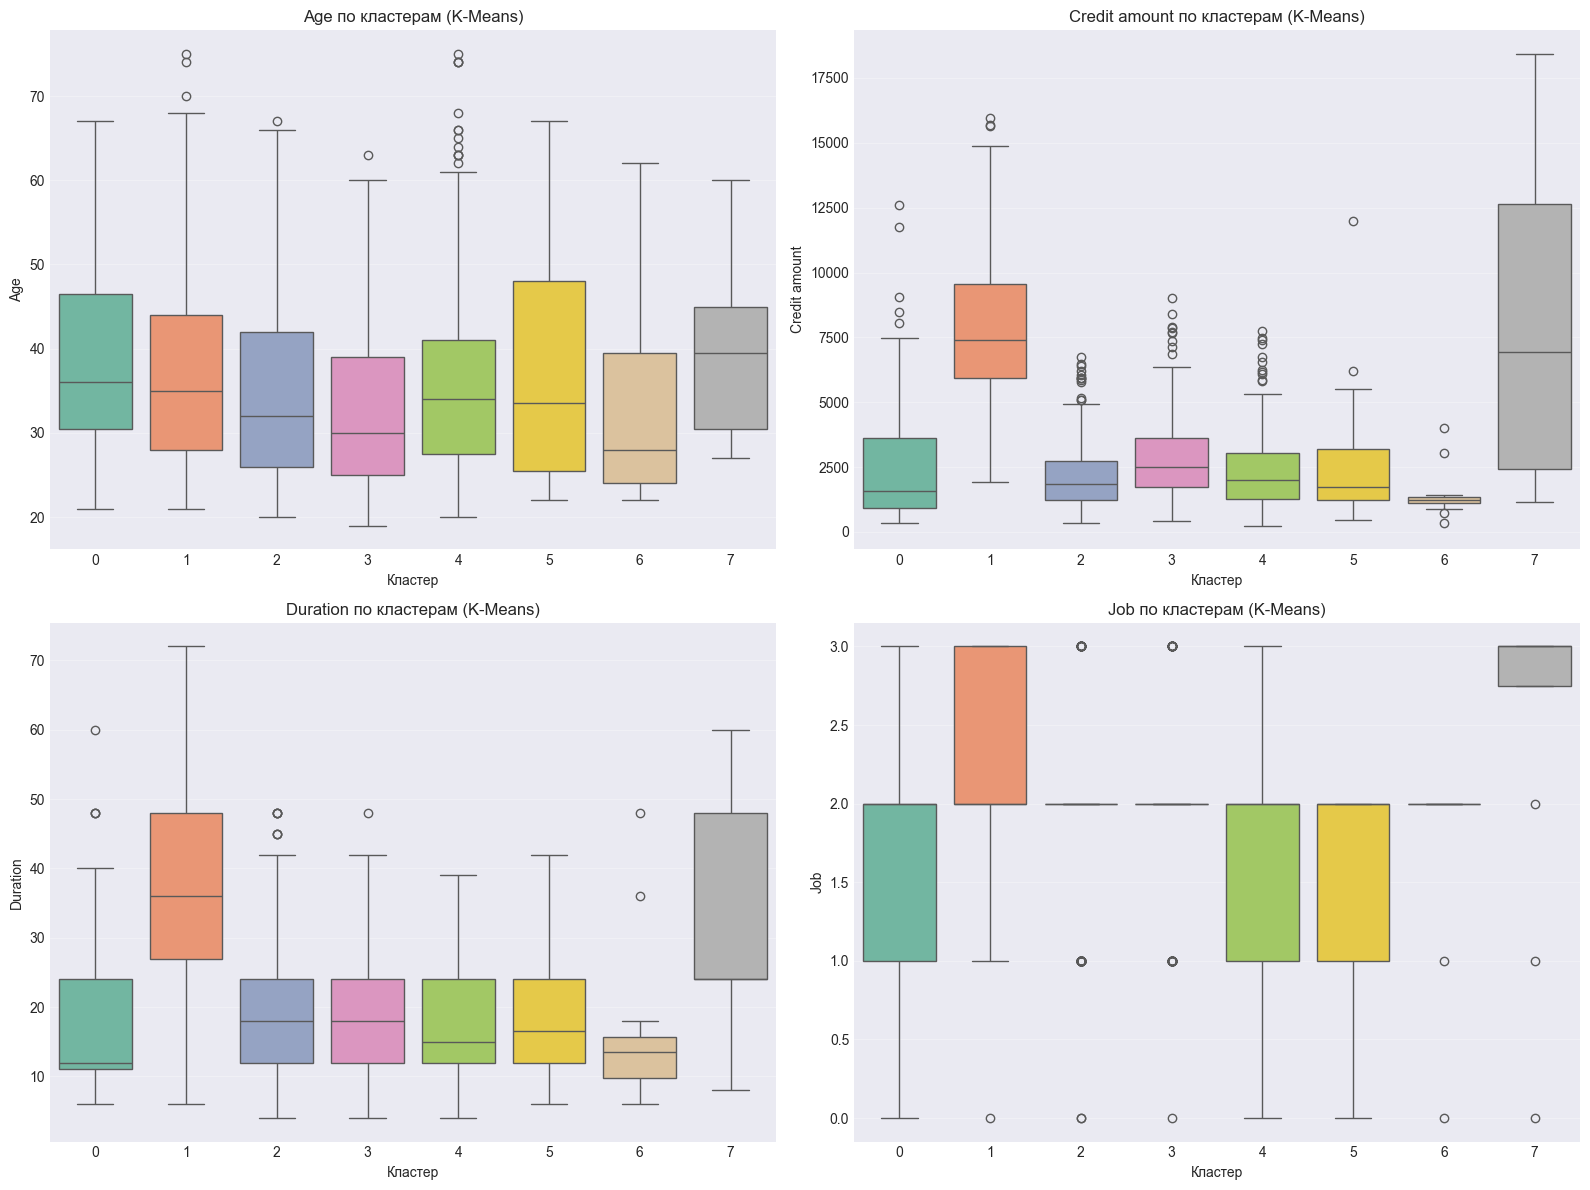

In [50]:
# 3.2 Boxplot-ы для ключевых признаков по кластерам
# Выбираем наиболее интерпретируемые признаки для визуализации
plot_features = ['Age', 'Credit amount', 'Duration', 'Job']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, feature in enumerate(plot_features):
    ax = axes[idx//2, idx%2]
    df_melted = df_processed[['kmeans_cluster', feature]].copy()
    df_melted['kmeans_cluster'] = df_melted['kmeans_cluster'].astype('category')

    sns.boxplot(x='kmeans_cluster', y=feature, data=df_melted, ax=ax, palette='Set2')
    ax.set_title(f'{feature} по кластерам (K-Means)')
    ax.set_xlabel('Кластер')
    ax.set_ylabel(feature)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

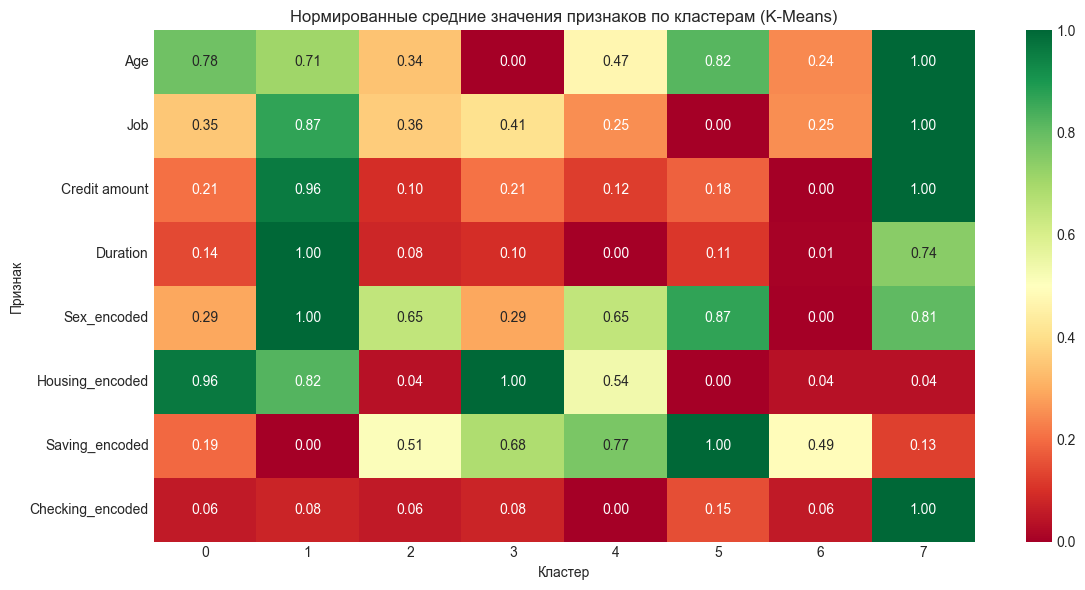

In [51]:
# 3.3 Дополнительные визуализации для интерпретации
# Heatmap средних значений (нормированных) для лучшего сравнения

# Нормируем средние значения для визуализации
cluster_stats_norm = cluster_stats.copy()
for col in cluster_stats_norm.columns:
    min_val = cluster_stats_norm[col].min()
    max_val = cluster_stats_norm[col].max()
    if max_val > min_val:
        cluster_stats_norm[col] = (cluster_stats_norm[col] - min_val) / (max_val - min_val)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_stats_norm.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5)
plt.title('Нормированные средние значения признаков по кластерам (K-Means)')
plt.xlabel('Кластер')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [52]:
print("ПРЕДВАРИТЕЛЬНАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (K-Means)")
for cluster_id in sorted(df_processed['kmeans_cluster'].unique()):
    cluster_data = df_processed[df_processed['kmeans_cluster'] == cluster_id]

    print(f"КЛАСТЕР {cluster_id} (n={len(cluster_data)})")

    # Основные характеристики
    avg_age = cluster_data['Age'].mean()
    avg_credit = cluster_data['Credit amount'].mean()
    avg_duration = cluster_data['Duration'].mean()
    avg_job = cluster_data['Job'].mean()

    print(f"• Средний возраст: {avg_age:.1f} лет")
    print(f"• Средняя сумма кредита: {avg_credit:,.0f} DM")
    print(f"• Средняя длительность: {avg_duration:.1f} месяцев")
    print(f"• Средний уровень работы (Job): {avg_job:.2f} (0-3)")

    # Доминирующая цель кредита
    purpose_cols = [col for col in df_processed.columns if col.startswith('Purpose_')]
    if purpose_cols:
        purpose_means = cluster_data[purpose_cols].mean()
        dominant_purpose = purpose_means.idxmax().replace('Purpose_', '') if purpose_means.max() > 0 else 'N/A'
        print(f"• Наиболее частая цель: {dominant_purpose}")

    # Распределение по сбережениям
    saving_dist = cluster_data['Saving_encoded'].value_counts(normalize=True) * 100
    print(f"• Распределение по сбережениям: {saving_dist.round(1).to_dict()}")


ПРЕДВАРИТЕЛЬНАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (K-Means)
КЛАСТЕР 0 (n=59)
• Средний возраст: 38.3 лет
• Средняя сумма кредита: 2,879 DM
• Средняя длительность: 19.7 месяцев
• Средний уровень работы (Job): 1.85 (0-3)
• Наиболее частая цель: education
• Распределение по сбережениям: {1: 57.6, 0: 25.4, 2: 8.5, 3: 5.1, 4: 3.4}
КЛАСТЕР 1 (n=141)
• Средний возраст: 37.7 лет
• Средняя сумма кредита: 7,925 DM
• Средняя длительность: 37.7 месяцев
• Средний уровень работы (Job): 2.37 (0-3)
• Наиболее частая цель: car
• Распределение по сбережениям: {1: 55.3, 0: 29.1, 2: 10.6, 4: 2.8, 3: 2.1}
КЛАСТЕР 2 (n=266)
• Средний возраст: 35.0 лет
• Средняя сумма кредита: 2,142 DM
• Средняя длительность: 18.4 месяцев
• Средний уровень работы (Job): 1.86 (0-3)
• Наиболее частая цель: radio/TV
• Распределение по сбережениям: {1: 62.0, 0: 17.3, 2: 9.4, 3: 8.3, 4: 3.0}
КЛАСТЕР 3 (n=177)
• Средний возраст: 32.4 лет
• Средняя сумма кредита: 2,898 DM
• Средняя длительность: 18.8 месяцев
• Средний уровень работы (Job): 1

,Method,Silhouette,Davies-Bouldin,N_clusters
0,K-Means,0.229,1.306,8
1,Hierarchical,0.219,1.298,7
2,DBSCAN,0.640,0.416,27


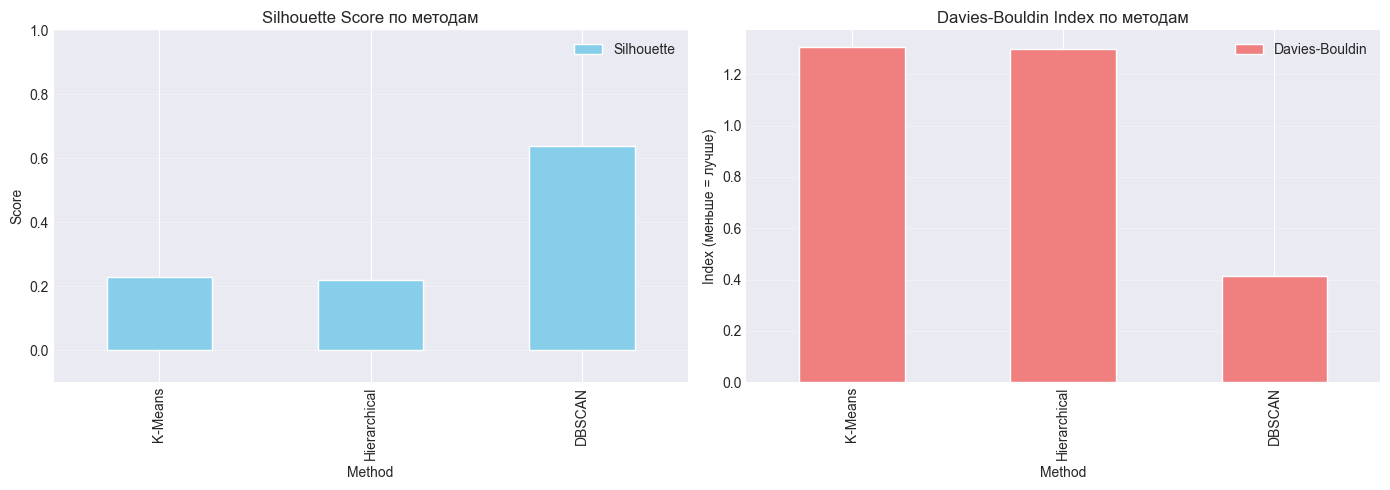

In [53]:
from sklearn.metrics import davies_bouldin_score

# 3.5 Сравнение методов кластеризации через silhouette score
# Исключаем шум из DBSCAN для расчета
mask_dbscan = df_processed['dbscan_cluster'] != -1

metrics_comparison = []

# K-Means
if len(df_processed['kmeans_cluster'].unique()) > 1:
    sil_kmeans = silhouette_score(X_scaled, df_processed['kmeans_cluster'])
    db_kmeans = davies_bouldin_score(X_scaled, df_processed['kmeans_cluster'])
    metrics_comparison.append({'Method': 'K-Means', 'Silhouette': sil_kmeans,
                              'Davies-Bouldin': db_kmeans, 'N_clusters': len(df_processed['kmeans_cluster'].unique())})

# Hierarchical
if len(df_processed['hier_cluster'].unique()) > 1:
    sil_hier = silhouette_score(X_scaled, df_processed['hier_cluster'])
    db_hier = davies_bouldin_score(X_scaled, df_processed['hier_cluster'])
    metrics_comparison.append({'Method': 'Hierarchical', 'Silhouette': sil_hier,
                              'Davies-Bouldin': db_hier, 'N_clusters': len(df_processed['hier_cluster'].unique())})

# DBSCAN
if mask_dbscan.sum() > 1 and len(np.unique(df_processed.loc[mask_dbscan, 'dbscan_cluster'])) > 1:
    sil_dbscan = silhouette_score(X_scaled[mask_dbscan], df_processed.loc[mask_dbscan, 'dbscan_cluster'])
    db_dbscan = davies_bouldin_score(X_scaled[mask_dbscan], df_processed.loc[mask_dbscan, 'dbscan_cluster'])
    n_clusters_dbscan = len(df_processed.loc[mask_dbscan, 'dbscan_cluster'].unique())
    metrics_comparison.append({'Method': 'DBSCAN', 'Silhouette': sil_dbscan,
                              'Davies-Bouldin': db_dbscan, 'N_clusters': n_clusters_dbscan})

metrics_df = pd.DataFrame(metrics_comparison)
display(metrics_df.round(3))

# Визуализация сравнения
if len(metrics_df) > 0:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Silhouette scores
    metrics_df.plot(x='Method', y='Silhouette', kind='bar', ax=ax[0], color='skyblue')
    ax[0].set_title('Silhouette Score по методам')
    ax[0].set_ylabel('Score')
    ax[0].set_ylim(-0.1, 1.0)
    ax[0].grid(axis='y', alpha=0.3)

    # Davies-Bouldin index (чем меньше, тем лучше)
    metrics_df.plot(x='Method', y='Davies-Bouldin', kind='bar', ax=ax[1], color='lightcoral')
    ax[1].set_title('Davies-Bouldin Index по методам')
    ax[1].set_ylabel('Index (меньше = лучше)')
    ax[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [54]:
# Сохранение обработанных данных с кластерами
output_file = 'german_credit_clustered.csv'
df_processed.to_csv(output_file, index=False)
print(f"\n Результаты сохранены в файл: {output_file}")

# Сохранение модели масштабирования для будущего использования
import joblib
joblib.dump(scaler, './scaler.pkl')
joblib.dump(kmeans_final, './kmeans_model.pkl')
print("Модели сохранены: scaler.pkl, kmeans_model.pkl")



 Результаты сохранены в файл: german_credit_clustered.csv
Модели сохранены: scaler.pkl, kmeans_model.pkl
